# this is the second google collab notebook for learning pytorch in detail, for PINNS from freecodecamp.org youtube video of 1 day, ya y heard it right
# here i will learn classification related problems

In [ ]:
# 1 gonna make some data
import sklearn
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
import numpy as np

n_samples = 1000

X,y = make_circles(n_samples, noise=0.03, random_state=42)
# z, w = make_circles(1000, factor=0.6, noise = 0.03, random_state=42)
# X = np.stack((X,z))
# X = X.unsqueeze()
print(len(z))
print(z[:5])
print(len(X.squeeze()))
print(X[:5])


1000
[[ 0.56116992  0.17931244]
 [-0.55882169  0.12073144]
 [-0.61696899  0.14821538]
 [-0.30857487  0.51191736]
 [ 0.44220765 -0.89672343]]
1000
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]


In [ ]:
import pandas as pd
circles = pd.DataFrame({"X1":X[:,0], "X2":X[:,1], "label":y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


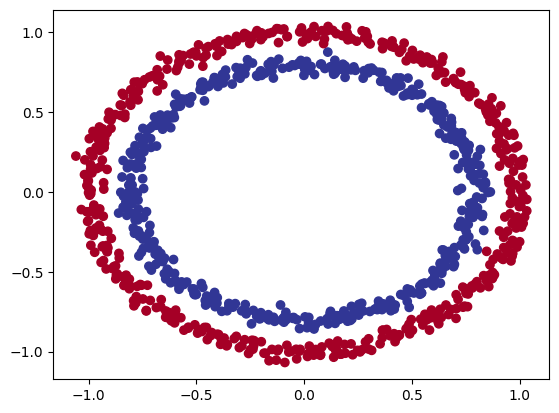

In [ ]:
plt.scatter(x = X[:,0], y = X[:,1], c=y, cmap=plt.cm.RdYlBu)

In [ ]:
# i think we can use linear classification here also, because that will make us a circle, in between red and blue dots, then we can take input and put that value inside the model,if the output is -ve then its inside and if outsude its positive,
X.shape# need to know the shape

(1000, 2)

In [ ]:
y.shape , X.dtype

((1000,), dtype('float64'))

In [ ]:
# turning data into tensor
import torch
from torch import nn

torch.__version__, print(X[:5])

[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]


('2.6.0+cu124', None)

In [ ]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
print(X[:10])

tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967],
        [-0.4796,  0.6764],
        [-0.0136,  0.8033],
        [ 0.7715,  0.1478],
        [-0.1693, -0.7935],
        [-0.1215,  1.0215]])


In [ ]:
#splitting data in training and test using sklearn its the best thing to split the data
from sklearn.model_selection import train_test_split
\
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=42)


In [ ]:
# writing device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
# now we will build our modeld
from sklearn import datasets
class CircleModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(2,20)
    self.relu = nn.ReLU()
    self.layer_2 = nn.Linear(20,20)
    self.layer_3= nn.Linear(20,1)
  def forward(self,x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_0 = CircleModel().to(device)

model_0,device # now we have device and model info
# i am not writing in nn.sequential form, its not good practice i think


(CircleModel(
   (layer_1): Linear(in_features=2, out_features=20, bias=True)
   (relu): ReLU()
   (layer_2): Linear(in_features=20, out_features=20, bias=True)
   (layer_3): Linear(in_features=20, out_features=1, bias=True)
 ),
 'cpu')

 Xavier/Glorot (nn.init.xavier_uniform_ or nn.init.xavier_normal_) — good for tanh/sigmoid.

Kaiming/He (nn.init.kaiming_uniform_ or nn.init.kaiming_normal_) — good for ReLU.

Bias → often just zero or small constan

In [ ]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.6951, -0.1710],
                      [-0.2906, -0.0263],
                      [-0.6011,  0.4405],
                      [ 0.3674,  0.5837],
                      [ 0.5680, -0.2049],
                      [ 0.3318,  0.5571],
                      [ 0.1850, -0.6807],
                      [ 0.6296, -0.6032],
                      [-0.0931, -0.2082],
                      [-0.0914, -0.1908],
                      [-0.2033, -0.6079],
                      [-0.2509, -0.7021],
                      [-0.4332, -0.5637],
                      [-0.1590, -0.0572],
                      [-0.5612, -0.5987],
                      [-0.4748,  0.6863],
                      [-0.1570, -0.5843],
                      [-0.6682, -0.2501],
                      [ 0.1310,  0.6734],
                      [-0.4213,  0.2373]])),
             ('layer_1.bias',
              tensor([ 0.0791, -0.6643,  0.2047, -0.0083,  0.6960, -0.1378, -0.4418, -0.1977,
 

In [ ]:
# make predictions
untrained_preds = model_0(X_test.to(device))
print(f"length of predictions: {len(untrained_preds)}, shpae: {untrained_preds.shape}")
print(f"length of test labels: {len(y_test)}, shape: {y_test.shape}")
print(f"untrained preds: {torch.round(untrained_preds[:10])}") # rounded to make o or 1.
print(f"test labels: {y_test[:10]}") # what should be the value.

length of predictions: 200, shpae: torch.Size([200, 1])
length of test labels: 200, shape: torch.Size([200])
untrained preds: tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], grad_fn=<RoundBackward0>)
test labels: tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [ ]:
 # this is shit, so lets fit our model

 # loss function
loss_function = nn.BCELoss() # requires inputs to have gone thorugh the sigmoid activation function prior to BCEloss
loss_function = nn.BCEWithLogitsLoss() # have sigmoid activation function in built

# optimizer
optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.11) # sgd optimizer used lr and decay, momentum, params, and many more here we are using only two

In [ ]:
# calculation of accuracy
def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

In [ ]:
# train # logits are only forward pass output not gone thorugh the activation function # for cuda use torch.cuda>manual_seed()
epochs = 1000
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
for epoch in range(epochs):
  model_0.train()
  # forward pass
  y_logits = model_0(X_train).squeeze()# its depends on yuor data
  y_pred = torch.round(torch.sigmoid(y_logits))
  #
  loss = loss_function(y_logits, y_train)# nn.BCEWithlogitsloss expect losits as input
  accuracy =  accuracy_fn(y_train,y_pred)

  #optimizer
  optimizer.zero_grad()
  #loss backwards
  loss.backward()
  #optim
  optimizer.step()
  ###testing

  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    #acc
    test_loss = loss_function(test_logits, y_test)
    test_acc = accuracy_fn(y_test,test_pred)

  # print info
  if epoch%10 == 0:
    print(f"epoch{epoch}| loss:{loss}| acc:{accuracy}| test loss:{test_loss}| test acc:{test_acc}")



epoch0| loss:0.6941929459571838| acc:55.625| test loss:0.6967757940292358| test acc:56.00000000000001
epoch10| loss:0.69223952293396| acc:51.5| test loss:0.6952739953994751| test acc:49.5
epoch20| loss:0.691088855266571| acc:52.75| test loss:0.6944490671157837| test acc:46.5
epoch30| loss:0.6902026534080505| acc:52.37500000000001| test loss:0.693849503993988| test acc:46.5
epoch40| loss:0.6894108653068542| acc:52.0| test loss:0.6933290362358093| test acc:47.0
epoch50| loss:0.6886593103408813| acc:52.0| test loss:0.6928394436836243| test acc:47.0
epoch60| loss:0.6879165768623352| acc:52.125| test loss:0.6923667788505554| test acc:47.0
epoch70| loss:0.6871679425239563| acc:52.25| test loss:0.6918936371803284| test acc:47.5
epoch80| loss:0.6864088177680969| acc:52.37500000000001| test loss:0.6914068460464478| test acc:48.0
epoch90| loss:0.6856349110603333| acc:52.87500000000001| test loss:0.6909047961235046| test acc:48.0
epoch100| loss:0.684838056564331| acc:53.37499999999999| test loss:

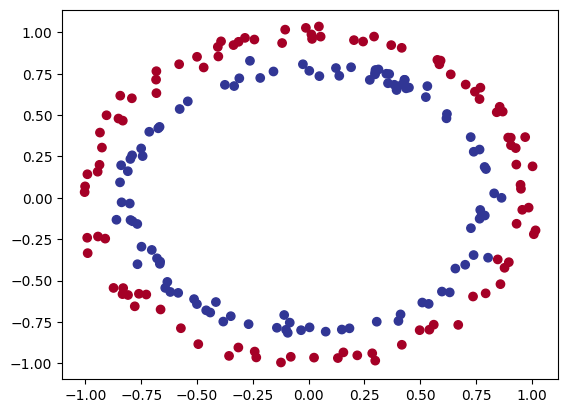

<function matplotlib.pyplot.show(close=None, block=None)>

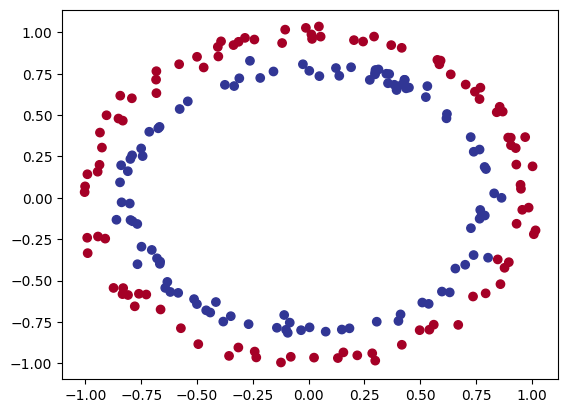

In [ ]:
plt.scatter(x = X_test[:,0].to('cpu').detach().numpy(), y = X_test[:,1].to('cpu').detach().numpy(), c=y_test.to('cpu').detach().numpy(), cmap=plt.cm.RdYlBu)
plt.show()
plt.scatter(x = X_test[:,0].to('cpu').detach().numpy(), y = X_test[:,1].to('cpu').detach().numpy(), c=test_pred.to('cpu').detach().numpy(), cmap=plt.cm.RdYlBu)
plt.show
#circles.label.value_counts()gives us how many y are and 1 and 0
# now this is shit our model is just splitting them by a line

In [ ]:
import requests
from pathlib import Path
if Path('helper_function.py').is_file():
  print('function laready exists, skipping downlaod')
else:
  request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py')
  with open('helper_function.py', 'wb') as f:
    f.write(request.content)
from helper_function import plot_predictions,plot_decision_boundary


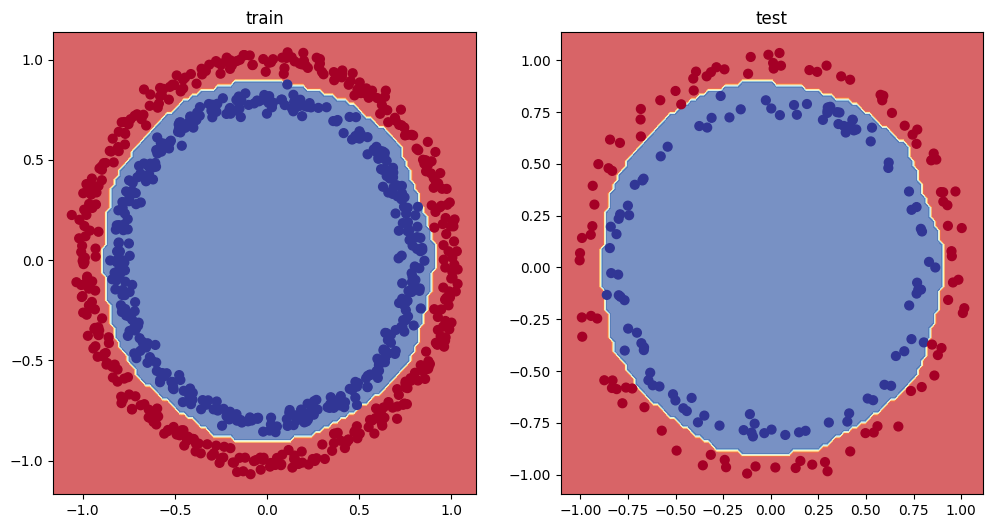

In [ ]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title('train')
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plt.title('test')
plot_decision_boundary(model_0,X_test,y_test) # place decision boundary like along which curve is our odel differentiating between different values

In [ ]:
# two learning learning rate is very importatn, and also the non-linearity in our model

In [ ]:
device

'cpu'

tensor([3., 2., 2., 1., 1., 2., 1., 2., 2., 1., 1., 3., 0., 2., 2., 2., 0., 0.,
        0., 1., 1., 3., 3., 3., 1., 1., 0., 0., 2., 1., 2., 2., 2., 0., 0., 3.,
        2., 1., 3., 3., 1., 2., 1., 3., 1., 3., 0., 1., 3., 1., 2., 0., 1., 3.,
        0., 3., 0., 0., 0., 2., 2., 0., 2., 3., 1., 0., 2., 2., 1., 0., 3., 0.,
        1., 2., 1., 3., 1., 0., 1., 0., 2., 0., 0., 0., 1., 3., 2., 2., 0., 0.,
        0., 0., 1., 1., 3., 1., 3., 0., 1., 2., 1., 3., 3., 0., 3., 1., 1., 0.,
        2., 0., 3., 2., 1., 1., 1., 1., 2., 3., 2., 1., 0., 2., 3., 1., 3., 2.,
        1., 3., 2., 1., 0., 2., 1., 3., 1., 3., 0., 2., 1., 1., 0., 0., 3., 3.,
        3., 1., 1., 0., 0., 0., 0., 3., 2., 2., 0., 1., 0., 1., 1., 3., 2., 0.,
        1., 2., 0., 0., 1., 2., 3., 2., 1., 0., 0., 1., 0., 3., 2., 3., 2., 3.,
        1., 1., 0., 2., 0., 2., 1., 3., 0., 2., 1., 0., 1., 1., 0., 3., 2., 2.,
        2., 3., 0., 2., 1., 0., 1., 1., 2., 0., 1., 2., 2., 3., 2., 2., 1., 0.,
        2., 0., 3., 1., 3., 3., 2., 0., 

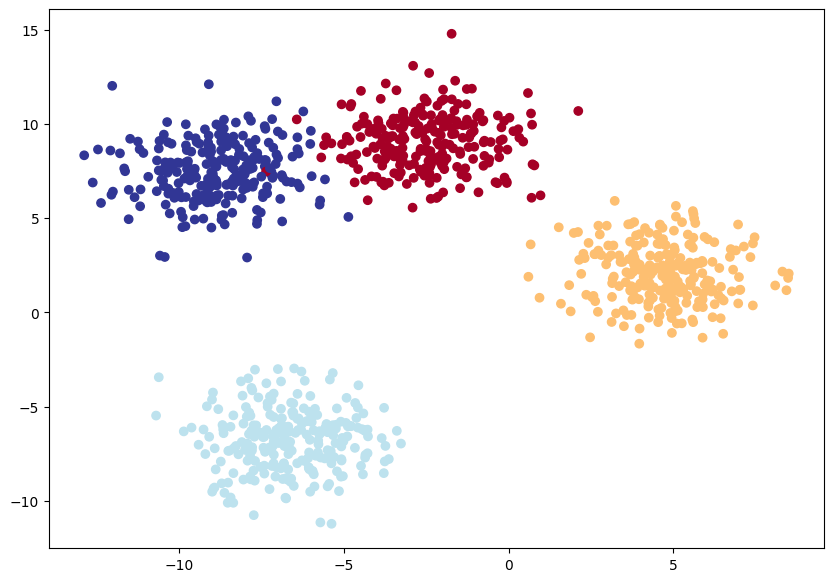

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob,y_blob = sklearn.datasets.make_blobs(n_samples=1000, n_features=NUM_FEATURES, centers=NUM_CLASSES, cluster_std=1.5,
                                            random_state=RANDOM_SEED, return_centers=False)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)

X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,y_blob,test_size=0.2, random_state = RANDOM_SEED)

plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0],X_blob[:,1],c=y_blob,cmap=plt.cm.RdYlBu)
print(y_blob)

In [ ]:
#lets use multiclass classification

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
class Blobmodel(nn.Module):
  def __init__(self,input_features, output_features, hidden_units=8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features)
    )
  def forward(self,x):
    return self.linear_layer_stack(x)

In [ ]:
X_blob_train.shape, y_blob_train[:5]


(torch.Size([800, 2]), tensor([1, 0, 2, 2, 0]))

In [ ]:
torch.unique(y_blob_train)

tensor([0, 1, 2, 3])

In [ ]:
model_1 = Blobmodel(2,4,8).to(device)
model_1

Blobmodel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [ ]:
# accuracy function
def accuracy_fn(pred,true):
  correct = np.equal(pred,true).sum().item()
  acc = (correct/len(pred))*100
  return acc

In [ ]:
#loss function
loss_function = nn.CrossEntropyLoss()

#optimixer
optimizer = torch.optim.SGD(params = model_1.parameters(), lr = 0.11)

In [ ]:
# lets train
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_blob_train = X_blob_train.to(device)
y_blob_train = y_blob_train.to(device)
X_blob_test = X_blob_test.to(device)
y_blob_test = y_blob_test.to(device)

epochs = 1000
for epoch in range(epochs):
  model_1.train()

  y_blob_logits = model_1(X_blob_train).squeeze()
  y_blob_pred  =  torch.softmax(y_blob_logits, dim=1).argmax(dim=1)
  # print(y_blob_pred)
  # print(y_blob_logits)
  # print(y_blob_train)
  y_blob_train = y_blob_train.type(torch.int64)
  loss = loss_function(y_blob_logits,y_blob_train)
  accuracy = accuracy_fn(y_blob_pred,y_blob_train)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
    test_blob_logits = model_1(X_blob_test)
    test_blob_pred = torch.softmax(test_blob_logits,dim=1).argmax(dim=1)
    y_blob_test = y_blob_test.type(torch.int64)# or torch.longtensor
    test_loss = loss_function(test_blob_logits,y_blob_test)
    test_acc = accuracy_fn(test_blob_pred,y_blob_test)
  if epoch%10 == 0:
    print(f"epoch:{epoch}| loss:{loss}| acc:{accuracy}| test-loss{test_loss}| test_acc{test_acc}")



/tmp/ipython-input-85-1649311607.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  correct = np.equal(pred,true).sum().item()


epoch:0| loss:1.1588267087936401| acc:40.375| test-loss1.067947268486023| test_acc49.5
epoch:10| loss:0.6211665868759155| acc:97.25| test-loss0.6346783638000488| test_acc98.0
epoch:20| loss:0.3883183002471924| acc:98.875| test-loss0.38968220353126526| test_acc100.0
epoch:30| loss:0.2046644240617752| acc:99.25| test-loss0.19164113700389862| test_acc99.5
epoch:40| loss:0.08702697604894638| acc:99.25| test-loss0.07798847556114197| test_acc99.5
epoch:50| loss:0.056984174996614456| acc:99.25| test-loss0.049147553741931915| test_acc99.5
epoch:60| loss:0.04555940628051758| acc:99.25| test-loss0.03759944811463356| test_acc99.5
epoch:70| loss:0.03956493362784386| acc:99.25| test-loss0.031084368005394936| test_acc99.5
epoch:80| loss:0.03576834127306938| acc:99.25| test-loss0.02714359574019909| test_acc99.5
epoch:90| loss:0.03329945355653763| acc:99.25| test-loss0.02450118213891983| test_acc99.5
epoch:100| loss:0.0315944105386734| acc:99.25| test-loss0.022586116567254066| test_acc99.5
epoch:110| 

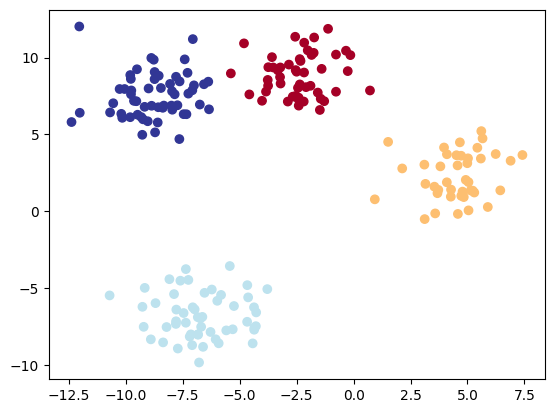

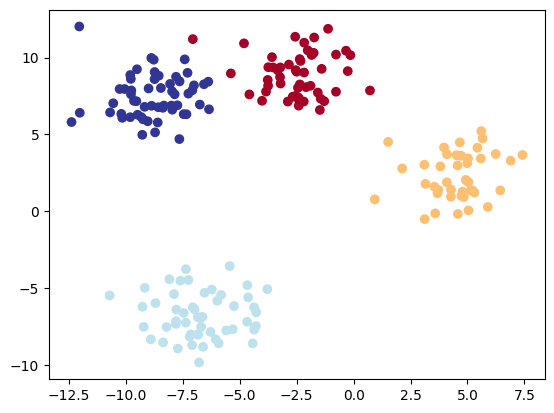

In [ ]:
plt.scatter(x = X_blob_test[:,0].to('cpu').detach().numpy(), y = X_blob_test[:,1].to('cpu').detach().numpy(), c=y_blob_test.to('cpu').detach().numpy(), cmap=plt.cm.RdYlBu)
plt.show()
plt.scatter(x = X_blob_test[:,0].to('cpu').detach().numpy(), y = X_blob_test[:,1].to('cpu').detach().numpy(), c=test_blob_pred.to('cpu').detach().numpy(), cmap=plt.cm.RdYlBu)
plt.show()
#circles.label.value_counts()gives us how many y are and 1 and 0
# now this is shit our model is just splitting them by a line

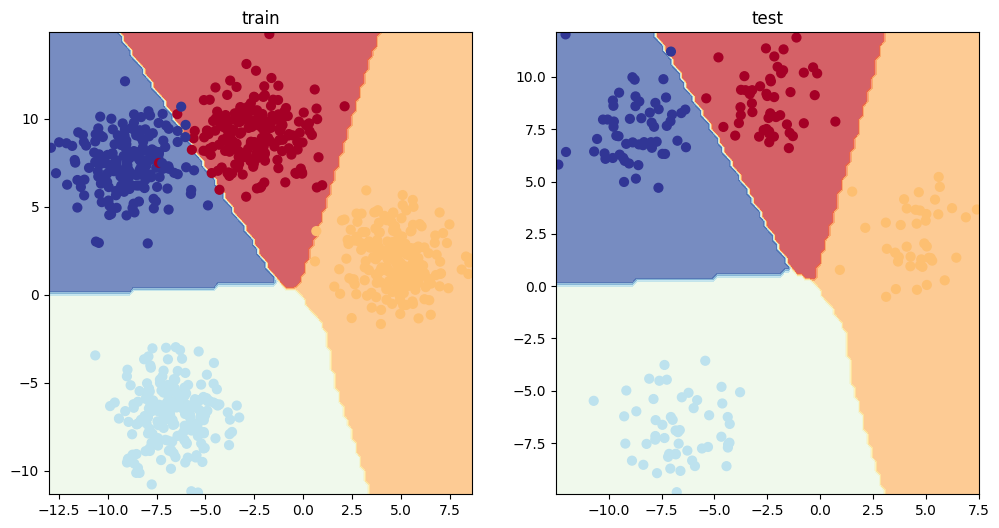

In [ ]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title('train')
plot_decision_boundary(model_1,X_blob_train,y_blob_train)
plt.subplot(1,2,2)
plt.title('tes boundary(model_1,X_blob_test,y_blob_test) # place decision boundary like along which curve is our odel differentiating between different values)

[[ 0.          0.        ]
 [ 0.00078356  0.01007057]
 [ 0.00414812  0.01977156]
 [ 0.00365087  0.0300823 ]
 [-0.000127    0.04040384]
 [ 0.00407199  0.05034063]
 [-0.00339881  0.06051068]
 [ 0.0044575   0.07056643]
 [ 0.0343836   0.07312807]
 [ 0.02470058  0.08748911]]


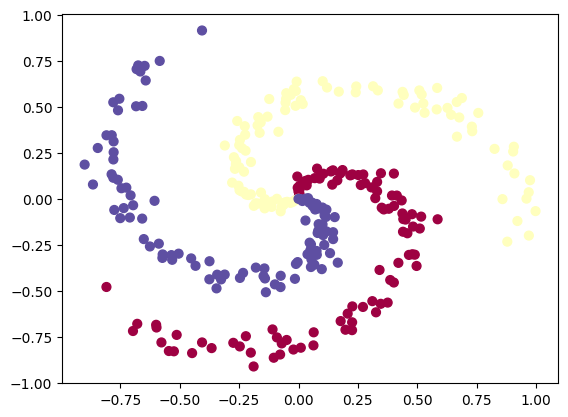

tensor([[ 0.0000,  0.0000],
        [ 0.0008,  0.0101],
        [ 0.0041,  0.0198],
        [ 0.0037,  0.0301],
        [-0.0001,  0.0404],
        [ 0.0041,  0.0503],
        [-0.0034,  0.0605],
        [ 0.0045,  0.0706],
        [ 0.0344,  0.0731],
        [ 0.0247,  0.0875]], dtype=torch.float64)


In [ ]:
# assignment
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data:
print(X[:10])
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

X = torch.from_numpy(X).type(torch.float64)
y = torch.from_numpy(y).type(torch.int64)
print(X[:10])

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
X_train[:5], y_train[:5]

(tensor([[-0.8450,  0.2760],
         [ 0.4343, -0.0086],
         [ 0.2257, -0.6701],
         [-0.0000, -0.0000],
         [ 0.1175, -0.1766]], dtype=torch.float64),
 tensor([2, 0, 0, 1, 2]))

In [ ]:
class spiralclassif(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=10):
    super().__init__()
    self.stacked_layers = nn.Sequential(
        nn.Linear(in_features=input_features,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=output_features)

    )
  def forward(self,X):
    return self.stacked_layers(X)
model_2 = spiralclassif(2,3,10)

In [ ]:
y_train.unique()

tensor([0, 1, 2])

In [ ]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model_2.parameters(), lr = 0.1)


In [ ]:
# lets train
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000
for epoch in range(epochs):
  model_2.t
# leaving training here, going head, as its just repititive